# GEE NASA GPM IMERG Downloader (Native Finest Resolution: 30-Menit)
Notebook ini didesain khusus dan modular untuk mengunduh produk presipitasi satelit global standar emas dunia **NASA GPM IMERG v07 (Integrated Multi-satellitE Retrievals for GPM)** pada **resolusi temporal terkecil aslinya: 30 MENIT (Half-Hourly)**.

### Spesifikasi Teknis (Mematuhi Rule 18 & Rule 5):
- **Koleksi GEE:** `NASA/GPM_L3/IMERG_V07` (Native 30-min Precipitation Calibrated, mm/jam).
- **Resolusi Temporal Asli:** 30 menit (48 citra/hari $\rightarrow$ 1.344 s.d. 1.488 time steps per file bulanan).
- **Sub-Monthly 15-Day Chunking (Rule 5 & Rule 18):** Untuk mematuhi batasan GEE maksimal 1024 band per ekspor, pengunduhan per bulan dibagi menjadi 2 part (Part 1: tgl 1-15 = 720 band; Part 2: tgl 16-akhir = 624-768 band), kemudian digabungkan secara seamless dengan `xarray.concat`.
- **Struktur Penyimpanan:** `data/imerg/<tahun>/imerg_<tahun>_<bulan:02d>.nc`.
- **Autentikasi 3-Tier:** Service Account Lokal (`.json`), Kaggle Secrets (`GEE_KEY`), dan browser fallback.

In [1]:
# =========================================================================
# 0. INSTALASI DEPENDENSI (JIKA DI RUN DI KAGGLE / ENVIRONMENT BARU)
# =========================================================================
!pip install geemap earthengine-api rioxarray geopandas xarray netCDF4 matplotlib --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.0 MB/s eta 0:00:00


In [2]:
# =========================================================================
import json
import os
import shutil
import glob
import calendar
from datetime import datetime, timedelta

import ee
import geopandas as gpd
import geemap
import rioxarray as rxr
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.validation import make_valid
from shapely.ops import transform, unary_union
from google.oauth2.service_account import Credentials

BASE_DIR = os.getcwd()

# Deteksi Lokasi File GeoJSON Administrasi Kebumen
if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    file_geojson = "/kaggle/input/datasets/jerismeteo/projek-downscale/33.05_kecamatan.geojson"
    if not os.path.exists(file_geojson):
        found_geo = glob.glob("/kaggle/input/**/33.05_kecamatan.geojson", recursive=True)
        file_geojson = found_geo[0] if found_geo else os.path.join(BASE_DIR, "33.05_kecamatan.geojson")
else:
    file_geojson = os.path.join(BASE_DIR, "33.05_kecamatan.geojson")

# Struktur Folder Output Native IMERG 30-Menit (Rule 3 & Rule 18)
FOLDER_IMERG = os.path.join(BASE_DIR, "data", "imerg")
os.makedirs(FOLDER_IMERG, exist_ok=True)

print(f"📌 File Batas Wilayah GeoJSON : {file_geojson}")
print(f"📌 Direktori Output IMERG 30m : {FOLDER_IMERG}")


📌 File Batas Wilayah GeoJSON : /kaggle/input/datasets/jerismeteo/projek-downscale/33.05_kecamatan.geojson
📌 Direktori Output IMERG 30m : /kaggle/working/data/imerg


In [3]:
# =========================================================================
# 2. INISIALISASI GOOGLE EARTH ENGINE (GEE)
# Mendukung: 1. Service Account Lokal (.json) | 2. Kaggle Secrets (GEE_KEY) | 3. Fallback Auth
# =========================================================================
import os
import json
import ee
from google.oauth2.service_account import Credentials

PROJECT_ID = 'staklimjerukagung'
init_success = False

# 1. Coba via Service Account File Lokal (Repo Projek_Downscale)
sa_candidates = [
    os.path.join(BASE_DIR, 'staklimjerukagung-b852a12a367e.json'),
    os.path.join(os.path.dirname(BASE_DIR), 'staklimjerukagung-b852a12a367e.json'),
    'staklimjerukagung-b852a12a367e.json'
]
for sa_path in sa_candidates:
    if os.path.exists(sa_path):
        try:
            with open(sa_path, 'r') as f:
                sa_info = json.load(f)
            SCOPES = ['https://www.googleapis.com/auth/earthengine']
            creds = Credentials.from_service_account_info(sa_info, scopes=SCOPES)
            ee.Initialize(credentials=creds, project=sa_info.get('project_id', PROJECT_ID))
            print(f"✅ Berhasil Inisialisasi GEE via File Service Account Lokal: {os.path.basename(sa_path)}")
            init_success = True
            break
        except Exception as e:
            print(f"⚠️ Gagal inisialisasi via SA file {sa_path}: {e}")

# 2. Coba via Kaggle User Secrets (Kaggle Environment: Add-ons -> Secrets -> GEE_KEY)
if not init_success:
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        sa_json_str = user_secrets.get_secret('GEE_KEY')
        sa_info = json.loads(sa_json_str)
        SCOPES = ['https://www.googleapis.com/auth/earthengine']
        creds = Credentials.from_service_account_info(sa_info, scopes=SCOPES)
        ee.Initialize(credentials=creds, project=sa_info.get('project_id', PROJECT_ID))
        print("✅ Berhasil Inisialisasi GEE via Kaggle Secret (GEE_KEY)")
        init_success = True
    except Exception as e:
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
            print(f"⚠️ Info Kaggle Secrets: {e}")
            print("💡 Tips di Kaggle: Buka menu Add-ons -> Secrets -> pastikan centang (checkbox) pada 'GEE_KEY' di notebook ini!")

# 3. Fallback ke Inisialisasi Default / Browser OAuth
if not init_success:
    try:
        ee.Initialize(project=PROJECT_ID)
        print("✅ Berhasil Inisialisasi GEE via Session Default")
    except Exception as e:
        print(f"ℹ️ Inisialisasi default gagal ({e}), membuka otentikasi browser GEE...")
        ee.Authenticate()
        ee.Initialize(project=PROJECT_ID)
        print("✅ Berhasil Autentikasi & Inisialisasi GEE via Browser")


✅ Berhasil Inisialisasi GEE via Kaggle Secret (GEE_KEY)


In [4]:
# =========================================================================
# 3. PERSIAPAN GEOMETRI & BOUNDING BOX (RULE 1)
# =========================================================================
if not os.path.exists(file_geojson):
    raise FileNotFoundError(f"File GeoJSON tidak ditemukan: {file_geojson}")

gdf = gpd.read_file(file_geojson)
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

print("Membersihkan topologi geometri...")
gdf = gdf[gdf.geometry.notna()].copy()

def _to_2d(geom):
    if geom is None or geom.is_empty: return None
    return transform(lambda x, y, z=None: (x, y), geom)

def _clean_geom(geom):
    if geom is None or geom.is_empty: return None
    geom = _to_2d(geom)
    geom = make_valid(geom)
    if geom is None or geom.is_empty: return None
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom.buffer(0)
    if geom.geom_type == "GeometryCollection":
        polys = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
        if polys:
            return unary_union(polys).buffer(0)
    return None

gdf["geometry"] = gdf["geometry"].apply(_clean_geom)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
gdf = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
gdf.reset_index(drop=True, inplace=True)

print("Mengonversi ke Google Earth Engine FeatureCollection...")
geojson_fc = gdf.__geo_interface__
batas_kebumen = ee.FeatureCollection(geojson_fc["features"])

# Ekstraksi BBox dengan Safety Buffer (Rule 1)
bounds = gdf.total_bounds
BUFFER_DEG = 0.02
ee_bbox = ee.Geometry.BBox(
    bounds[0] - BUFFER_DEG,  # min Lon (West)
    bounds[1] - BUFFER_DEG,  # min Lat (South)
    bounds[2] + BUFFER_DEG,  # max Lon (East)
    bounds[3] + BUFFER_DEG   # max Lat (North)
)

print(f"✅ Batas Geometri Siap!")
print(f"   Extent Asli: Lon [{bounds[0]:.4f}, {bounds[2]:.4f}], Lat [{bounds[1]:.4f}, {bounds[3]:.4f}]")
print(f"   Extent BBox: Lon [{bounds[0]-BUFFER_DEG:.4f}, {bounds[2]+BUFFER_DEG:.4f}], Lat [{bounds[1]-BUFFER_DEG:.4f}, {bounds[3]+BUFFER_DEG:.4f}]")


Membersihkan topologi geometri...
Mengonversi ke Google Earth Engine FeatureCollection...
✅ Batas Geometri Siap!
   Extent Asli: Lon [109.3788, 109.8393], Lat [-7.8312, -7.4457]
   Extent BBox: Lon [109.3588, 109.8593], Lat [-7.8512, -7.4257]


In [5]:
# =========================================================================
# 4. FUNGSI UNDUH NATIVE IMERG 30-MENIT DENGAN 15-DAY CHUNKING (RULE 5 & 18)
# =========================================================================
def unduh_imerg_halfhourly_bulanan(tahun, bulan, batas_ee, ee_bbox, output_base_dir):
    """
    Mengunduh presipitasi NASA GPM IMERG v07 setengah jam (30-menit / half-hourly)
    selama 1 bulan penuh (1344 - 1488 citra).
    Mematuhi Rule 5: dibagi menjadi 2 sub-stack (Part 1: tgl 1-15, Part 2: tgl 16-akhir),
    masing-masing <= 768 band (<= 1024 band limit GEE), lalu digabungkan dengan xarray.
    """
    folder_tahun = os.path.join(output_base_dir, str(tahun))
    os.makedirs(folder_tahun, exist_ok=True)

    nc_path = os.path.join(folder_tahun, f"imerg_{tahun}_{bulan:02d}.nc")
    if os.path.exists(nc_path):
        print(f"[{tahun}-{bulan:02d}] ✓ File 30-menit sudah ada: {nc_path} (Dilewati)")
        return nc_path

    sub_ranges = [
        ("part1", f"{tahun}-{bulan:02d}-01", f"{tahun}-{bulan:02d}-16"),
        ("part2", f"{tahun}-{bulan:02d}-16", f"{tahun+1}-01-01" if bulan == 12 else f"{tahun}-{bulan+1:02d}-01")
    ]

    parts_da = []
    temp_files = []

    print(f"[{tahun}-{bulan:02d}] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...\n")
    try:
        for p_name, t_start, t_end in sub_ranges:
            tif_part = os.path.join(folder_tahun, f"temp_imerg_{tahun}_{bulan:02d}_{p_name}.tif")
            temp_files.append(tif_part)

            col_sub = (ee.ImageCollection("NASA/GPM_L3/IMERG_V07")
                       .filterBounds(ee_bbox)
                       .filterDate(t_start, t_end)
                       .select('precipitation'))

            n_scenes = col_sub.size().getInfo()
            if n_scenes == 0:
                print(f"[{tahun}-{bulan:02d}] {p_name}: Tidak ada scene di GEE.")
                continue

            timestamps = col_sub.aggregate_array('system:time_start').getInfo()
            part_time_idx = pd.to_datetime(timestamps, unit='ms')

            stacked_part = col_sub.toBands().clip(ee_bbox)

            print(f"[{tahun}-{bulan:02d}] Ekspor {p_name} ({n_scenes} bands <= 1024) ke GeoTIFF temporer...")
            geemap.ee_export_image(
                stacked_part,
                filename=tif_part,
                region=ee_bbox,
                scale=11132,  # 0.10 derajat (~11 km)
                file_per_band=False
            )

            with rxr.open_rasterio(tif_part, masked=True) as da:
                da = da.rename({'band': 'time'})
                da['time'] = part_time_idx[:len(da.time)]
                da.name = "precipitation"
                parts_da.append(da.load())

        if not parts_da:
            print(f"[{tahun}-{bulan:02d}] ⚠️ Gagal mengumpulkan data IMERG.")
            return None

        # Gabungkan Part 1 dan Part 2 sepanjang dimensi waktu (time: 1344..1488)
        if len(parts_da) == 1:
            ds_full = parts_da[0].to_dataset(name="precipitation")
        else:
            merged_da = xr.concat(parts_da, dim="time")
            ds_full = merged_da.to_dataset(name="precipitation")

        ds_full.attrs["source"] = "NASA/GPM_L3/IMERG_V07"
        ds_full.attrs["temporal_resolution"] = "Half-Hourly (30-Minute)"
        ds_full.attrs["units"] = "mm/hr"
        ds_full.attrs["long_name"] = "Half-hourly Precipitation (GPM IMERG v07 Final Run)"
        ds_full.to_netcdf(nc_path)
        ds_full.close()

        for f in temp_files:
            if os.path.exists(f): os.remove(f)

        print(f"[{tahun}-{bulan:02d}] ✓ Sukses! Tersimpan NetCDF 30-menit: {nc_path} ({len(ds_full.time)} steps)\n")
        return nc_path

    except Exception as e:
        print(f"[{tahun}-{bulan:02d}] ❌ Error: {e}")
        for f in temp_files:
            if os.path.exists(f): os.remove(f)
        return None


In [6]:
# =========================================================================
# 5. EKSEKUSI BATCH UNDUH IMERG 30-MENIT MULTI-TAHUN
# =========================================================================
TAHUN_MULAI = 2000
TAHUN_SELESAI = 2026
BULAN_MULAI = 1
BULAN_SELESAI = 12

print("=" * 75)
print(f"🚀 MEMULAI PIPELINE BATCH PENGUNDUHAN GPM IMERG 30-MENIT ({TAHUN_MULAI} - {TAHUN_SELESAI})")
print("=" * 75)

for tahun in range(TAHUN_MULAI, TAHUN_SELESAI + 1):
    b_start = BULAN_MULAI if tahun == TAHUN_MULAI else 1
    b_end = BULAN_SELESAI if tahun == TAHUN_SELESAI else 12
    for bulan in range(b_start, b_end + 1):
        unduh_imerg_halfhourly_bulanan(tahun, bulan, batas_kebumen, ee_bbox, FOLDER_IMERG)

print("=" * 75)
print("🎉 BATCH SELESAI!")
print("=" * 75)


🚀 MEMULAI PIPELINE BATCH PENGUNDUHAN GPM IMERG 30-MENIT (2000 - 2026)
[2000-01] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2000-01] Ekspor part1 (720 bands <= 1024) ke GeoTIFF temporer...
Generating URL ...
Please wait ...
Data downloaded to /kaggle/working/data/imerg/2000/temp_imerg_2000_01_part1.tif


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


[2000-01] Ekspor part2 (768 bands <= 1024) ke GeoTIFF temporer...
Generating URL ...
Please wait ...
Data downloaded to /kaggle/working/data/imerg/2000/temp_imerg_2000_01_part2.tif


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


[2000-01] ✓ Sukses! Tersimpan NetCDF 30-menit: /kaggle/working/data/imerg/2000/imerg_2000_01.nc (1488 steps)

[2000-02] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2000-02] Ekspor part1 (720 bands <= 1024) ke GeoTIFF temporer...
Generating URL ...
Please wait ...
Data downloaded to /kaggle/working/data/imerg/2000/temp_imerg_2000_02_part1.tif


...

[2026-08] Ekspor part2 (768 bands <= 1024) ke GeoTIFF temporer...
Generating URL ...
Please wait ...
Data downloaded to /kaggle/working/data/imerg/2026/temp_imerg_2026_08_part2.tif


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


[2026-08] ✓ Sukses! Tersimpan NetCDF 30-menit: /kaggle/working/data/imerg/2026/imerg_2026_08.nc (1488 steps)

[2026-09] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2026-09] Ekspor part1 (440 bands <= 1024) ke GeoTIFF temporer...
Generating URL ...
Please wait ...
Data downloaded to /kaggle/working/data/imerg/2026/temp_imerg_2026_09_part1.tif


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


[2026-09] part2: Tidak ada scene di GEE.
[2026-09] ✓ Sukses! Tersimpan NetCDF 30-menit: /kaggle/working/data/imerg/2026/imerg_2026_09.nc (440 steps)

[2026-10] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2026-10] part1: Tidak ada scene di GEE.
[2026-10] part2: Tidak ada scene di GEE.
[2026-10] ⚠️ Gagal mengumpulkan data IMERG.
[2026-11] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2026-11] part1: Tidak ada scene di GEE.
[2026-11] part2: Tidak ada scene di GEE.
[2026-11] ⚠️ Gagal mengumpulkan data IMERG.
[2026-12] Mengambil koleksi IMERG V07 30-menit (Native Finest Resolution)...

[2026-12] part1: Tidak ada scene di GEE.
[2026-12] part2: Tidak ada scene di GEE.
[2026-12] ⚠️ Gagal mengumpulkan data IMERG.
🎉 BATCH SELESAI!


🔍 Memverifikasi Sample File: /kaggle/working/data/imerg/2026/imerg_2026_09.nc
<xarray.Dataset> Size: 56kB
Dimensions:        (time: 440, y: 5, x: 6)
Coordinates:
  * time           (time) datetime64[ns] 4kB 2026-09-01 ... 2026-09-10T03:30:00
  * y              (y) float64 40B -7.45 -7.55 -7.65 -7.75 -7.85
  * x              (x) float64 48B 109.4 109.5 109.6 109.7 109.8 109.9
Data variables:
    spatial_ref    int64 8B ...
    precipitation  (time, y, x) float32 53kB ...
Attributes:
    source:               NASA/GPM_L3/IMERG_V07
    temporal_resolution:  Half-Hourly (30-Minute)
    units:                mm/hr
    long_name:            Half-hourly Precipitation (GPM IMERG v07 Final Run)

Total time steps: 440 (Resolusi asli 30-menit)
Rentang waktu: 2026-09-01T00:00:00.000000000 s.d. 2026-09-10T03:30:00.000000000


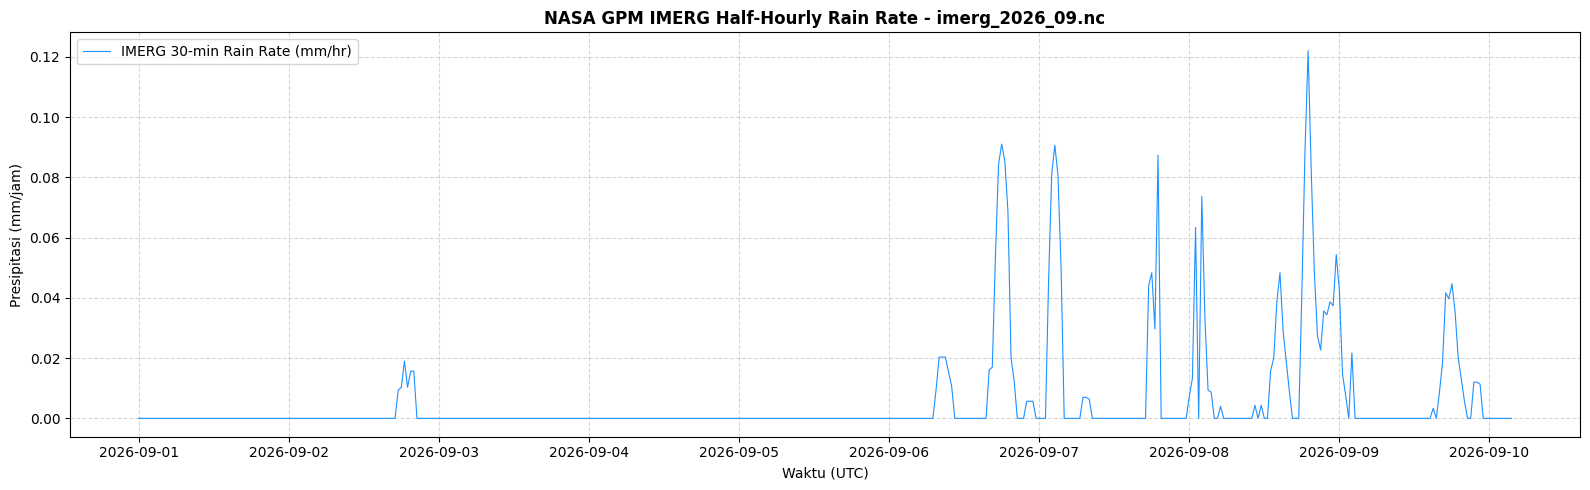

In [7]:
# =========================================================================
# 6. VERIFIKASI DIMENSI & RESOLUSI WAKTU 30-MENIT (TIME-SERIES INSPECTION)
# =========================================================================
list_nc = sorted(glob.glob(os.path.join(FOLDER_IMERG, "*", "*.nc")))

if not list_nc:
    print("⚠️ Belum ada file NetCDF IMERG di direktori output.")
else:
    sample_file = list_nc[-1]
    print(f"🔍 Memverifikasi Sample File: {sample_file}")
    with xr.open_dataset(sample_file) as ds:
        print(ds)
        print(f"\nTotal time steps: {len(ds.time)} (Resolusi asli 30-menit)")
        print(f"Rentang waktu: {ds.time.values[0]} s.d. {ds.time.values[-1]}")
        
        # Plot Time Series Rata-Rata Spasial
        ts = ds['precipitation'].mean(dim=['x', 'y'])
        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(ds.time.values, ts.values, color='dodgerblue', lw=0.8, label='IMERG 30-min Rain Rate (mm/hr)')
        ax.set_title(f"NASA GPM IMERG Half-Hourly Rain Rate - {os.path.basename(sample_file)}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Presipitasi (mm/jam)")
        ax.set_xlabel("Waktu (UTC)")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()
        plt.tight_layout()
        plt.show()
